# Frame the problem

- predict car prices based on a number of features
- this problem is a supervised, univariate regression problem
- we can use the rmse as the performance measure for this problem

# Get the data

In [46]:
import pandas as pd

car_details = pd.read_csv("./dataset/car_details.csv")
car_details.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [47]:
car_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


this dataset is really clean in that there are no null values. however, the dataset is pretty small.

In [48]:
car_details["owner"].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

In [49]:
car_details.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [50]:
most_expensive_idx = car_details['selling_price'].idxmax()
car_details['name'][most_expensive_idx]

'Audi RS7 2015-2019 Sportback Performance'

preliminary thoughts:
- the name might be a pretty important feature to determine car prices (luxury brands are usually much more expensive)
- owner, year, and km_driven are all metrics that relate to use and age, which will also have good correlation with the price

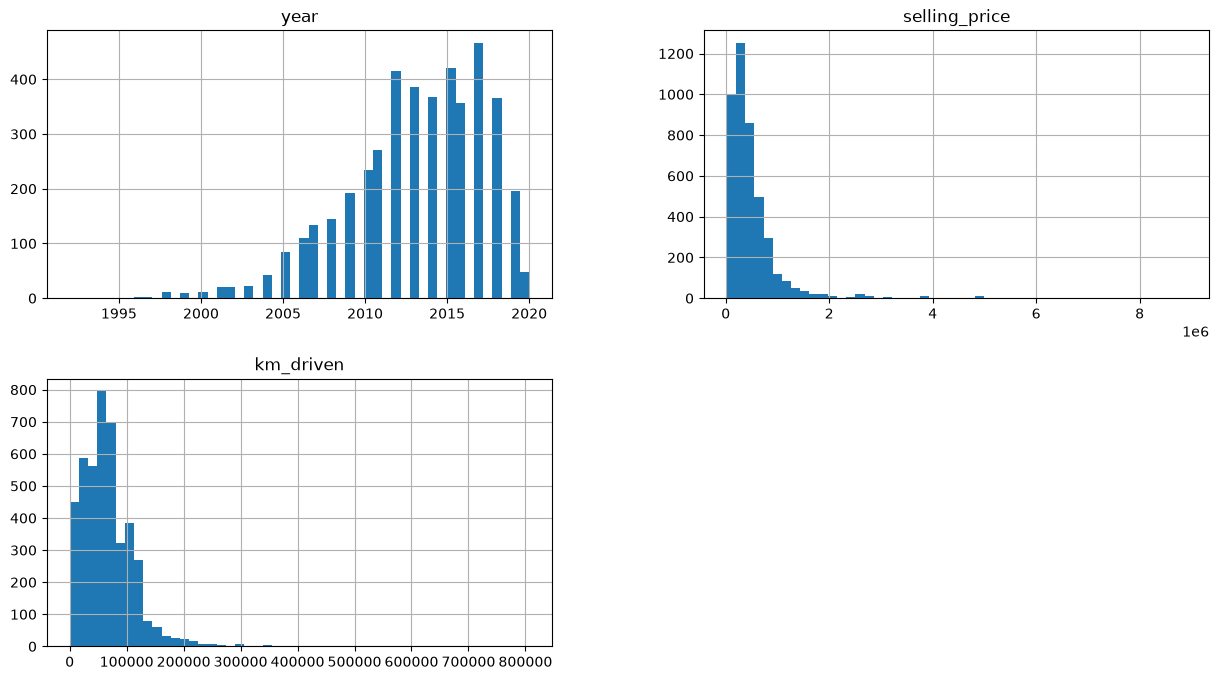

In [51]:
import matplotlib.pyplot as plt

car_details.hist(bins=50, figsize=(15,8))
plt.show()

couple things to note now for later eda looking at the histograms:
- selling_price and km_driven are exponential curves/skewed right, so we can apply the log transformation to get the nice bell curve shape
- the features have very different scales, so we should apply some sort of scaling transformation

## Create the test set

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(car_details, test_size=0.2, random_state=42, shuffle=True) # since we don't know too much about which features are important, we can try random instead of statified sampling
cars = train_set.copy()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
227,Mahindra Scorpio S11 BSIV,2017,1500000,20000,Diesel,Individual,Manual,First Owner
964,Maruti Swift Dzire VDI,2018,500000,50000,Diesel,Individual,Manual,First Owner
2045,Maruti Alto 800 LXI,2013,92800,25000,Petrol,Individual,Manual,Second Owner
1025,Chevrolet Beat Diesel LS,2011,95000,70000,Diesel,Individual,Manual,First Owner
4242,Maruti Vitara Brezza LDi Option,2017,685000,72000,Diesel,Dealer,Manual,First Owner
...,...,...,...,...,...,...,...,...
3444,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2006,500000,50000,Diesel,Individual,Manual,First Owner
466,Tata Indica Vista Quadrajet LX,2011,133000,80000,Diesel,Individual,Manual,First Owner
3092,Maruti Ciaz VDi Plus SHVS,2016,665000,51000,Diesel,Dealer,Manual,First Owner
3772,Maruti Ertiga VDI,2013,250999,80000,Diesel,Individual,Manual,First Owner
